In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import jit


### Variable

In [2]:
dim = 100
I = 1 # A
hx = 1 # pas spatial
hy = 1 # pas spatial

x = np.linspace(0, dim, dim)
y = np.linspace(0, dim, dim)

xx, yy = np.meshgrid(x, y)

# demi_dist = 5

A = (98, 46)
B = (98, 54)
# M = (48, 98)
# N = (51, 98)

M = (98, 48)
N = (98, 52)


### On met une matrice de conductivité

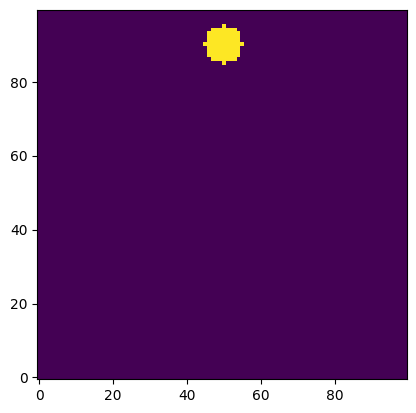

In [3]:
sigma_init = np.ones((dim, dim))# np.random.uniform(low=1, high=10, size=(dim, dim))

xx, yy = np.meshgrid(np.arange(dim), np.arange(dim), indexing='ij')

sigma_init[(xx-90)**2 + (yy-50)**2 <= 5**2] = 1000


# sigma_init[: 90, dim//2 - 50: dim//2 + 50] = 1000

pot_init = np.zeros((dim, dim))

courant_init = np.zeros((dim, dim))
courant_init[A[0]:dim, A[1]] = I
courant_init[B[0]:dim, B[1]] = -I

plt.figure()
plt.imshow(sigma_init, origin='lower')

# plt.imshow(courant_init, origin='lower')



### Calcul du potentiel

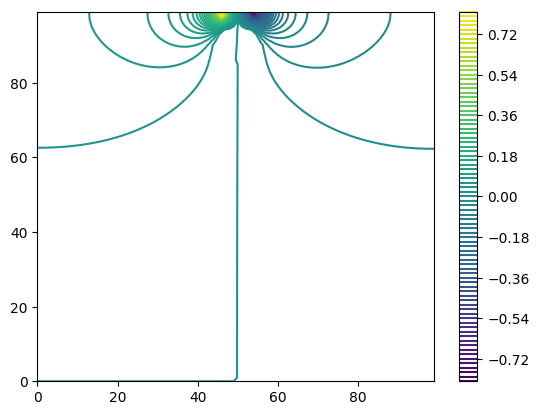

In [4]:
import numpy as np
import numba

@numba.njit(fastmath=True, parallel=True)
def compute_pot(V, V_k, Sigma, I):
    l = V.shape[0]
    h2 = 1.0  # h^2

    for j in numba.prange(1, l-1):
        for i in range(1, l-1):

            s = Sigma[j, i]

            sip = Sigma[j, i+1]
            sim = Sigma[j, i-1]
            sjp = Sigma[j+1, i]
            sjm = Sigma[j-1, i]

            sigma_ifhs = 2*s*sip / (s + sip)
            sigma_ibhs = 2*s*sim / (s + sim)
            sigma_jfhs = 2*s*sjp / (s + sjp)
            sigma_jbhs = 2*s*sjm / (s + sjm)

            deno = sigma_ifhs + sigma_ibhs + sigma_jfhs + sigma_jbhs

            V[j, i] = (
                I[j, i]*h2
                + sigma_ifhs*V_k[j, i+1]
                + sigma_ibhs*V_k[j, i-1]
                + sigma_jfhs*V_k[j+1, i]
                + sigma_jbhs*V_k[j-1, i]
            ) / deno

    return V


@numba.njit(fastmath=True)
def compute_error(V, V_k):
    err = 0.0
    for j in range(V.shape[0]):
        for i in range(V.shape[1]):
            d = V[j, i] - V_k[j, i]
            err += d*d
    return np.sqrt(err)


@numba.njit(fastmath=True)
def apply_bc(V, DIM):
    # conditions limites
    V[0, :] = 0
    V[-1, :] = V[-2, :]
    V[:, 0] = V[:, 1]
    V[:, DIM-1] = V[:, DIM-2]


@numba.njit(fastmath=True)
def find_pot(V, Sigma, I, DIM, tol=1e-5, niter=1000000):

    for it in range(niter):

        V_k = V.copy()

        apply_bc(V, DIM)

        compute_pot(V, V_k, Sigma, I)

        error = compute_error(V, V_k)

        if error < tol:
            break

    return V

Voltage = find_pot(pot_init, sigma_init, courant_init, DIM=dim)

# print(f"Nombre d'itérations: {it}")
# print(f"Erreur: {error}")


plt.figure()
# plt.imshow(Voltage, origin='lower')
plt.contour(Voltage, levels=100)
# plt.imshow(pot)
plt.colorbar()
                

### Mesure de la différence de potentiel

In [5]:
# def coord_schlumb(A_i, B_i, max_dist):
#     A_to_move = A_i[1]
#     B_to_move = B_i[1]
#     A_list = []
#     B_list = []
#     for i in range(2, max_dist, 2):
#         A = A_to_move - i
#         B = B_to_move + i
#         A_list.append(A)
#         B_list.append(B)

#     return list(zip(A_list, B_list))

# c = coord_schlumb(A, B, 45)

# def pot_for_schlumb(V, M, N):

#     dV = V[M[0], M[1]] - V[N[0], N[1]]
#     return dV


# def app_res(coord_ab, dimension, cond, I):
#     V_i = np.zeros((dimension, dimension))

#     rho_app = []
#     AB_2 = []

#     for i in coord_ab:
#         a, b = i
#         AB_2.append(abs(b-a)/2)
#         I0 = np.zeros((dimension, dimension))
#         V_i = np.zeros((dimension, dimension))
#         I0[98:, a]=I
#         I0[98:, b]=-I

#         V = find_pot(V_i, cond, I0, DIM=dimension)

#         V_MN = pot_for_schlumb(V, M, N)

#         # print(M, N)
#         # print(a, b)

#         K = np.pi * (((abs(b-a)/2)**2 - (abs(M[1]-N[1])/2)**2) / abs(M[1]-N[1]))#(2 * np.pi) / ((1/abs(a-M[1])) - (1/abs(b-M[1])) - (1/abs(a-N[1])) + (1/abs(b-N[1])))

#         rho_ap = K*V_MN/I
#         rho_app.append(rho_ap)

#     return np.array(rho_app), np.array(AB_2)

# rho_a, ab2 = app_res(c, dim, sigma_init, I)






In [6]:
import numpy as np
from joblib import Parallel, delayed

def coord_schlumb(A_i, B_i, max_dist):
    A_to_move = A_i[1]
    B_to_move = B_i[1]
    A_list = []
    B_list = []
    for i in range(2, max_dist, 2):
        A = A_to_move - i
        B = B_to_move + i
        A_list.append(A)
        B_list.append(B)

    return list(zip(A_list, B_list))

c = coord_schlumb(A, B, 45)

def compute_one_ab(a, b, dimension, cond, I, M, N):
    # Injection courant
    I0 = np.zeros((dimension, dimension))
    I0[98, a] = I
    I0[98, b] = -I

    # Solveur
    V = find_pot(np.zeros((dimension, dimension)), cond, I0, DIM=dimension)

    # Différence de potentiel
    dV = V[M[0], M[1]] - V[N[0], N[1]]

    # Géométrie
    AB = abs(b - a)
    AB_2 = AB / 2

    MN_dist = abs(M[1] - N[1])
    MN_term = (MN_dist / 2)**2

    K = np.pi * ((AB_2**2 - MN_term) / MN_dist)

    rho = K * dV / I

    return rho, AB_2


def app_res_parallel(coord_ab, dimension, cond, I, M, N, n_jobs=-1):

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_one_ab)(a, b, dimension, cond, I, M, N)
        for (a, b) in coord_ab
    )

    rho_app, AB_2 = zip(*results)

    return np.array(rho_app), np.array(AB_2)

In [7]:
rho_a, ab2 = app_res_parallel(c, dim, sigma_init, I, M, N)

### Résistivité apparente du sol

Text(0.5, 0, 'Demi-distance entre les électrodes [m]')

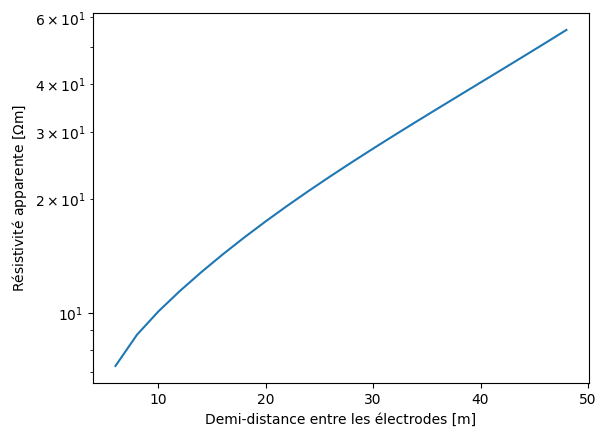

In [8]:


plt.figure()
# plt.contourf(xx, yy, V_[0], levels=200)
plt.plot(ab2, rho_a)
plt.yscale('log')
plt.ylabel(r"Résistivité apparente [$\Omega$m]")
plt.xlabel("Demi-distance entre les électrodes [m]")

# plt.show()

### On trouve la pseudo-section

La pseudo-section est un "mapping" de la résistivité apparent du sous-sol.

In [9]:
def pseudo_section(dimension, cond, I):
    # pseudo = np.zeros((dimension, dimension))
    rho = []
    x = []
    z = []

    A_i = [dimension-2, 2]
    M_i = [dimension-2, 4]
    N_i = [dimension-2, 6]
    B_i = [dimension-2, 8]

    A_i_modif = A_i.copy()
    B_i_modif = B_i.copy()
    M_i_modif = M_i.copy()
    N_i_modif = N_i.copy()

    ligne = dimension-2
    while B_i_modif[1] - A_i_modif[1] <= dimension-2:

        a, b, m, n = A_i_modif[1], B_i_modif[1], M_i_modif[1], N_i_modif[1]

        print(B_i_modif[1] - A_i_modif[1])
        print(a, m, n, b)

        I0 = np.zeros((dimension, dimension))
        V_i = np.zeros((dimension, dimension))
        
        I0[A_i_modif[0], A_i_modif[1]]=I
        I0[B_i_modif[0], B_i_modif[1]]=-I

        V = find_pot(V_i, cond, I0, DIM=dimension)

        V_MN = V[M_i_modif[0], M_i_modif[1]] - V[N_i_modif[0], N_i_modif[1]]#pot_for_schlumb(V, M_i_modif, N_i_modif)

        K = np.pi * (((abs(b-a)/2)**2 - (abs(m-n)/2)**2) / abs(m-n))
        
        x_i = (m + n)//2
        z_i = abs(b-a)//2
        x.append(x_i)
        z.append(z_i)
        # pseudo[ligne, centre] = K*V_MN/I
        rho.append(K*V_MN/I)
        A_i_modif[1] += 10
        B_i_modif[1] += 10
        M_i_modif[1] += 10
        N_i_modif[1] += 10

        if B_i_modif[1] >= dimension-2:
            ligne -= 1
            A_i_modif[1] = 2
            B_i_modif[1] = B_i[1] + 8
            M_i_modif[1] = M_i[1] + 4
            N_i_modif[1] = N_i[1] + 4
            A_i[1] += 4
            B_i[1] += 8
            M_i[1] += 4
            N_i[1] += 4
            # M_i_modif[1] += 1
            # N_i_modif[1] += 1

    return np.array(x), np.array(z), np.array(rho)

In [10]:
pseudo_section_array = pseudo_section(dim, sigma_init, I)
# plt.imshow(pseudo_section_array, origin='lower')

6
2 4 6 8
6
12 14 16 18
6
22 24 26 28
6
32 34 36 38
6
42 44 46 48
6
52 54 56 58
6
62 64 66 68
6
72 74 76 78
6
82 84 86 88
14
2 8 10 16
14
12 18 20 26
14
22 28 30 36
14
32 38 40 46
14
42 48 50 56
14
52 58 60 66
14
62 68 70 76
14
72 78 80 86
14
82 88 90 96
22
2 12 14 24
22
12 22 24 34
22
22 32 34 44
22
32 42 44 54
22
42 52 54 64
22
52 62 64 74
22
62 72 74 84
22
72 82 84 94
30
2 16 18 32
30
12 26 28 42
30
22 36 38 52
30
32 46 48 62
30
42 56 58 72
30
52 66 68 82
30
62 76 78 92
38
2 20 22 40
38
12 30 32 50
38
22 40 42 60
38
32 50 52 70
38
42 60 62 80
38
52 70 72 90
46
2 24 26 48
46
12 34 36 58
46
22 44 46 68
46
32 54 56 78
46
42 64 66 88
54
2 28 30 56
54
12 38 40 66
54
22 48 50 76
54
32 58 60 86
54
42 68 70 96
62
2 32 34 64
62
12 42 44 74
62
22 52 54 84
62
32 62 64 94
70
2 36 38 72
70
12 46 48 82
70
22 56 58 92
78
2 40 42 80
78
12 50 52 90
86
2 44 46 88
94
2 48 50 96


[ 5 15 25 35 45 55 65 75 85  9 19 29 39 49 59 69 79 89 13 23 33 43 53 63
 73 83 17 27 37 47 57 67 77 21 31 41 51 61 71 25 35 45 55 65 29 39 49 59
 69 33 43 53 63 37 47 57 41 51 45 49] [ 3  3  3  3  3  3  3  3  3  7  7  7  7  7  7  7  7  7 11 11 11 11 11 11
 11 11 15 15 15 15 15 15 15 19 19 19 19 19 19 23 23 23 23 23 27 27 27 27
 27 31 31 31 31 35 35 35 39 39 43 47] [  5.92796188   5.31698809   5.27017678   5.22128164   4.8412215
   4.8416698    5.22244596   5.2723321    5.32622674  16.49507831
  14.14012601  13.73643158  12.61237738   8.11490243  12.07914647
  13.65367085  14.06807762  15.84429521  26.9304944   22.92587089
  21.08753098  17.80721169  12.83624535  19.93015182  22.38721236
  24.83381096  37.34485052  31.18808164  28.43665425  16.97974353
  25.61946588  29.0578406   33.31892111  47.17521685  39.52142013
  37.08000763  16.45855181  38.66588092  40.48464079  56.50702943
  51.76616405  35.66205675  35.85460752  52.14495501  70.10015003
  62.13637363  23.71187088  59.34112382

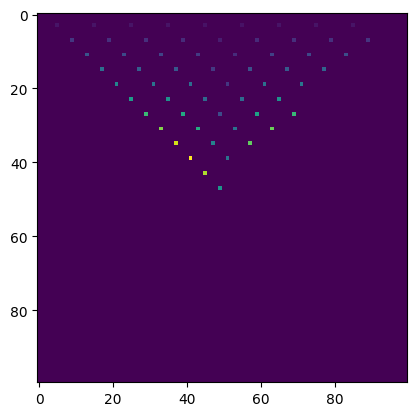

In [11]:
# plt.figure()
# plt.imshow(pseudo_section_array, origin='lower')
# plt.show()
x, z, rho_app = pseudo_section_array

print(x, z, rho_app)
pseudo = np.zeros((dim, dim))

for idx, i in enumerate(x):
    pseudo[z[idx], x[idx]] = rho_app[idx]

plt.imshow(pseudo)

# from scipy.interpolate import griddata

# # grille régulière
# xi = np.linspace(x.min(), x.max(), 200)
# zi = np.linspace(z.min(), z.max(), 200)

# XI, ZI = np.meshgrid(xi, zi)

# # interpolation
# RHOI = griddata((x, z), rho_app, (XI, ZI), method='cubic')

# plt.figure(figsize=(10, 5))

# # contour rempli
# plt.contourf(XI, ZI, RHOI, levels=100)
# # plt.imshow(RHOI, origin='lower')

# # points de mesure (optionnel mais pro)
# plt.scatter(x, z, c='k', s=10)

# plt.gca().invert_yaxis()  # profondeur vers le bas

# plt.xlabel("Position (x)")
# plt.ylabel("Profondeur apparente (AB/2)")

# plt.title("Pseudo-section de résistivité apparente")

# plt.colorbar(label="Résistivité apparente (Ohm·m)")

# plt.tight_layout()
# plt.show()